In [9]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
#Henry Hub Natural Gas
df_ng = yf.download("NG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Copper
df_cu = yf.download("HG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Brent
df_bz = yf.download("BZ=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Corn
df_zc = yf.download("ZC=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Crude Oil WTI
df_cl = yf.download("CL=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cattle-Live
df_le = yf.download("LE=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cocoa
df_cc = yf.download("CC=F", start="2016-01-01", end="2026-08-31", interval="1d")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
df_ng.columns

MultiIndex([( 'Close', 'NG=F'),
            (  'High', 'NG=F'),
            (   'Low', 'NG=F'),
            (  'Open', 'NG=F'),
            ('Volume', 'NG=F')],
           names=['Price', 'Ticker'])

### Log returns

In [4]:
try:
    for df in [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]:
        df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
        df['Percentage_Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df.drop(['Close', 'High', 'Low', 'Open'], axis=1, inplace=True)
        df.drop(df.index[0], inplace=True)
except Exception as e:
    pass

/Users/anandjoy/Documents/projects/Ian/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Data cleaning

<Axes: xlabel='Date'>

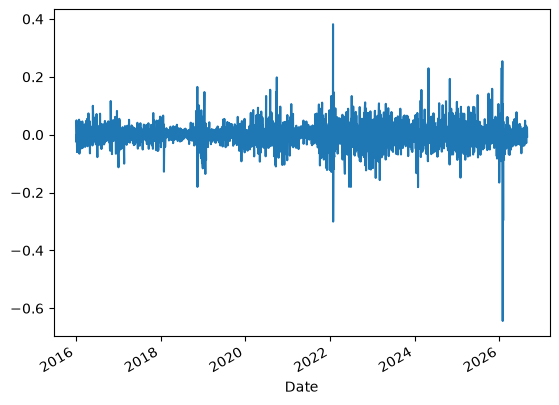

In [7]:
df_ng['Log_Returns'].plot()

In [ ]:
def plot_histogram(df:pd.DataFrame | pd.DataFrame, bins:int=50):
    mean = df.mean()
    std = df.std()
    plt.hist(
        df,
        bins=50,
        edgecolor='black',
        alpha=0.6,
        color='skyblue',
    )
    plt.axvline(
        mean, color='black', linestyle='-', linewidth=2, label=f'Mean ({mean:.2f}%)'
    )
    sigma_colors = {1: 'orange', 2: 'red', 3: 'purple'}
    for i, color in sigma_colors.items():
        pos_val = mean + i * std
        neg_val = mean - i * std
        plt.axvline(
            pos_val,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f'+{i}$\sigma$ ({pos_val:.2f}%)',
        )
        plt.axvline(
            neg_val,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f'-{i}$\sigma$ ({neg_val:.2f}%)',
        )
    # Formatting
    plt.title('Histogram of Percentage Return with $\sigma$ Boundaries', fontsize=14)
    plt.xlabel('Percentage Return (%)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mn/l_3fpssx7lgd3ztl3f0dcb040000gn/T/ipykernel_87865/1732973782.py:23: SyntaxWarning: invalid escape sequence '\s'
  label=f'+{i}$\sigma$ ({pos_val:.2f}%)',
/var/folders/mn/l_3fpssx7lgd3ztl3f0dcb040000gn/T/ipykernel_87865/1732973782.py:30: SyntaxWarning: invalid escape sequence '\s'
  label=f'-{i}$\sigma$ ({neg_val:.2f}%)',
/var/folders/mn/l_3fpssx7lgd3ztl3f0dcb040000gn/T/ipykernel_87865/1732973782.py:33: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Histogram of Percentage Return with $\sigma$ Boundaries', fontsize=14)


AttributeError: 'Series' object has no attribute 'columns'

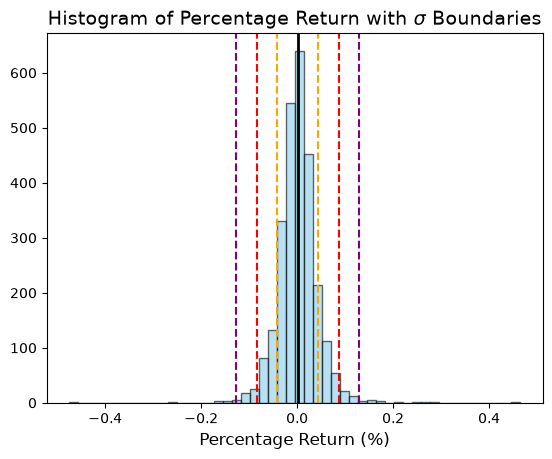

In [14]:
plot_histogram(df_ng['Percentage_Returns'], bins=50)